In [11]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet, BayesianRidge
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import GridSearchCV
import joblib

# Data Preprocessings

In [29]:
df = pd.read_csv(r'airfoil.csv')
# Check missing values
if df.isnull().sum().sum() == 0:
    print("No missing values in the dataset. Data shape:", df.shape)
else:
    raise ValueError("Dataset contains missing values. Please handle them before proceeding.")

# Encode categorical feature
labelencoder = LabelEncoder()
df['Airfoil'] = labelencoder.fit_transform(df['Airfoil'])
print("Airfoil classes:", labelencoder.classes_)

# Define features and target column
features_cols = ['Alpha', 'Reynolds', 'Airfoil']
target_col = 'Cl/Cd'

# Split data into training and test sets
X = df[features_cols]
y = df[target_col]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
print(f"Training set shape: {X_train.shape}, Test set shape: {X_test.shape}")

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Feature scaling completed.")

No missing values in the dataset. Data shape: (5869, 4)
Airfoil classes: ['naca0012' 'naca1412' 'naca2412' 'naca4412' 'naca6412']
Training set shape: (4108, 3), Test set shape: (1761, 3)
Feature scaling completed.


# Modeling and Evaluation

In [132]:
# Define models with default parameters
models = {
    'SVR': SVR(**{'C': 1.0, 'epsilon': 0.1, 'kernel': 'rbf'}),
    'Linear Regression': LinearRegression(),
    'Lasso': Lasso(alpha=1.0),
    'Ridge': Ridge(alpha=1.0),
    'ElasticNet': ElasticNet(alpha=1.0, l1_ratio=0.5),
    'BayesianRidge': BayesianRidge(),
    'MLP': MLPRegressor(hidden_layer_sizes=(64, 64),
                        activation='relu',
                        solver='adam',
                        max_iter=500,
                        random_state=42)
    
}

In [133]:
# Define performance metrics
metrics = {
    'MAE': mean_absolute_error,
    'MSE': mean_squared_error,
    'R2': r2_score
}

In [134]:
def evaluate_model(metrics, model, name, X_test, y_test, results_df):
    y_pred = model.predict(X_test)

    # Store results in DataFrame
    for metric_name, metric_func in metrics.items():
        results_df.loc[name, metric_name] = metric_func(y_test, y_pred)
    return results_df

In [135]:
results_df = pd.DataFrame(columns=list(metrics.keys()), index=models.keys())
for name, model in models.items():
    model= model.fit(X_train_scaled, y_train)
    model_results = evaluate_model(metrics, model, name, X_test_scaled, y_test, results_df)
print(model_results)

                         MAE          MSE        R2
SVR                 8.271851   138.072932  0.928285
Linear Regression  24.242959   932.652293  0.515583
Lasso              24.249253   938.627649  0.512479
Ridge              24.243289   932.667612  0.515575
ElasticNet         25.915247  1058.627359  0.450151
BayesianRidge      24.243989   932.699874  0.515558
MLP                 3.182371    18.871498  0.990198


##### From this result, SVR and MLP show the best performance in terms of R2 score. 
##### However, the performance of each model can be further improved by tuning hyperparameters using GridSearchCV.

# Tuning

In [136]:
# Hyperparameter tuning for SVR using GridSearchCV
svr_params = {
    'C': [1000, 3000, 5000],
    'epsilon': [0.01, 0.1, 0.2],
    'kernel': ['rbf'],
    'gamma': ['scale', 'auto', 0.1, 0.01]
}

svr_grid = GridSearchCV(
    SVR(),
    svr_params,
    scoring='r2',
    cv=5,
    n_jobs=-1
)

svr_grid.fit(X_train_scaled, y_train)

print("Best SVR params:", svr_grid.best_params_)
print("Best SVR R2:", svr_grid.best_score_)

Best SVR params: {'C': 5000, 'epsilon': 0.2, 'gamma': 'auto', 'kernel': 'rbf'}
Best SVR R2: 0.9883542292597063


In [137]:
# Hyperparameter tuning for MLP using GridSearchCV
mlp_params = {
    'hidden_layer_sizes': [(32,), (64, 64), (128, 64)],
    'activation': ['relu', 'tanh'],
    'alpha': [0.0001, 0.001, 0.01],
    'learning_rate_init': [0.001, 0.01],
    'max_iter': [500]
}

mlp_grid = GridSearchCV(
    MLPRegressor(random_state=42),
    mlp_params,
    scoring='r2',
    cv=5,
    n_jobs=-1
)

mlp_grid.fit(X_train_scaled, y_train)

print("Best MLP params:", mlp_grid.best_params_)
print("Best MLP R2:", mlp_grid.best_score_)

Best MLP params: {'activation': 'tanh', 'alpha': 0.0001, 'hidden_layer_sizes': (64, 64), 'learning_rate_init': 0.001, 'max_iter': 500}
Best MLP R2: 0.9913653878762674


In [138]:
models = {"SVR": svr_grid.best_estimator_, "MLP": mlp_grid.best_estimator_}
results_df = pd.DataFrame(columns=list(metrics.keys()), index=models.keys())
for name, model in models.items():
    model_results = evaluate_model(metrics, model, name, X_test_scaled, y_test, results_df)
print(model_results)

          MAE        MSE        R2
SVR  3.220208  22.742304  0.988188
MLP  3.046455  17.416994  0.990954


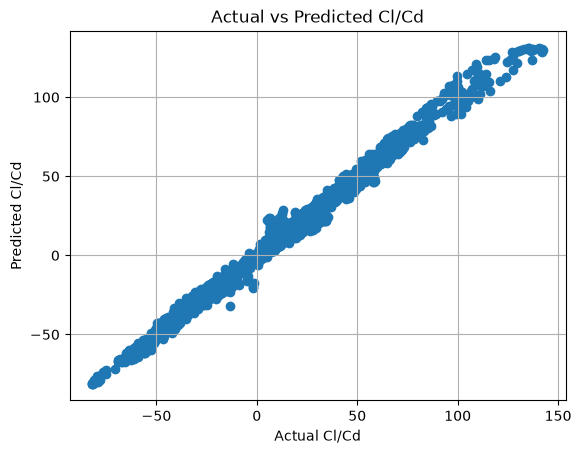

In [53]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Cl/Cd")
plt.ylabel("Predicted Cl/Cd")
plt.title("Actual vs Predicted Cl/Cd")
plt.grid(True)
plt.show()


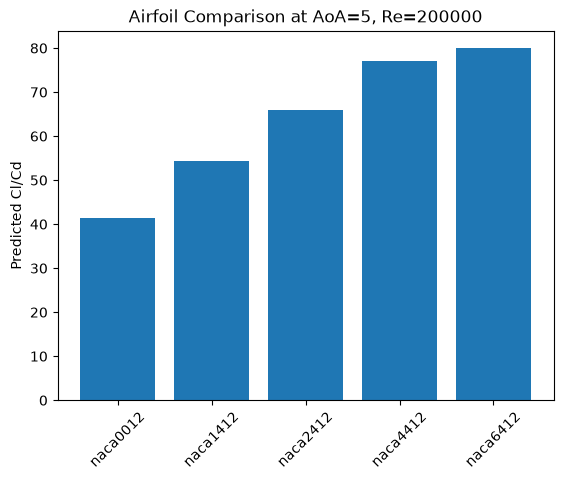

In [62]:
alpha = 5
re = 200000

preds = predict_all_airfoils(model, scaler, alpha, re, airfoil_labels)

plt.bar(airfoil_labels, preds)
plt.xticks(rotation=45)
plt.ylabel("Predicted Cl/Cd")
plt.title(f"Airfoil Comparison at AoA={alpha}, Re={re}")
plt.show()

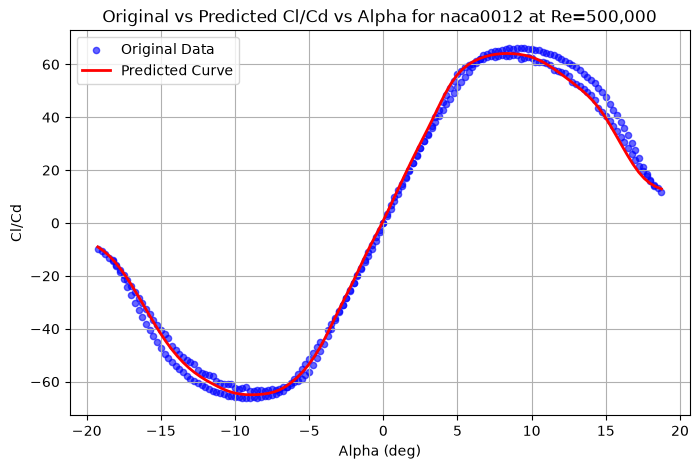

In [92]:
airfoil_name = "naca0012"

df_filtered = df[
    (df["Airfoil"] == airfoil_name) &
    (df["Reynolds"] == 500000)
].sort_values("Alpha")

plt.figure(figsize=(8,5))

# Original data (smaller dots)
plt.scatter(
    df_filtered["Alpha"],
    df_filtered["Cl/Cd"],
    s=20,              # smaller dots
    color="blue",
    alpha=0.6,
    label="Original Data"
)

# Predicted smooth curve
alphas = np.linspace(df_filtered["Alpha"].min(), df_filtered["Alpha"].max(), 100)
plt.plot(
    alphas,
    preds,
    color="red",
    linewidth=2,
    label="Predicted Curve"
)

plt.xlabel("Alpha (deg)")
plt.ylabel("Cl/Cd")
plt.title(f"Original vs Predicted Cl/Cd vs Alpha for {airfoil_name} at Re=500,000")
plt.legend()
plt.grid(True)
plt.show()

In [139]:
best_model = mlp_grid.best_estimator_

In [ ]:
joblib.dump(best_model, "./artifacts/best_model.pkl")
joblib.dump(scaler, "./artifacts/scaler.pkl")
joblib.dump(labelencoder.classes_, "./artifacts/labelencoder.pkl")

['labelencoder.pkl']